# Domácí úkol č. 3 - 📈 Vizualizace ve strojovém učení od A do Z

## Michal {Kopča, Holý}
## kopcami2 | holymich

Import potrebných knižníc:

In [1]:
#tu sú všetky použité knižnice
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

V našej úlohe sme sa rozhodli pre dataset winequalityN.csv zo stránky Kaggle (https://www.kaggle.com/datasets/rajyellow46/wine-quality).

Načítame si súboru 'winequalityN.csv' do dataframu df. Taktiež sme si vytvorili kópiu learn_df ktorú použijeme na strojové učenie:

In [2]:
df = pd.read_csv('winequalityN.csv')
learn_df = df.copy()

In [3]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


V našom datasete sa nachádzajú informácie o jednotlivých variantách portugalského vína "Vinho Verde", podľa ktorého budeme predikovať jeho kvalitu na škále 1-10.

Tieto informácie sú následovné:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Ošetrenie chýbajúcich hodnôt

Aby sme mohli pracovať s chýbajucími hodnotami musíme ich identifikovať, zistiť ich počet a ako sú v našom datasete reprezentované.

In [5]:
df. shape

(6497, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


Z pozorovaní sme zistili, že niektoré premenné obsahujú chýbajúce hodnoty.  
Avšak ich počet je rovný iba zlomku percenta, čo môže spôsobiť, že vizualizácia týchto hodnôt môže mať nízku informačnú hodnotu.  

Rozloženie počtu týchto hodnôt si môžeme prehladne ukázať na koláčovom grafe:

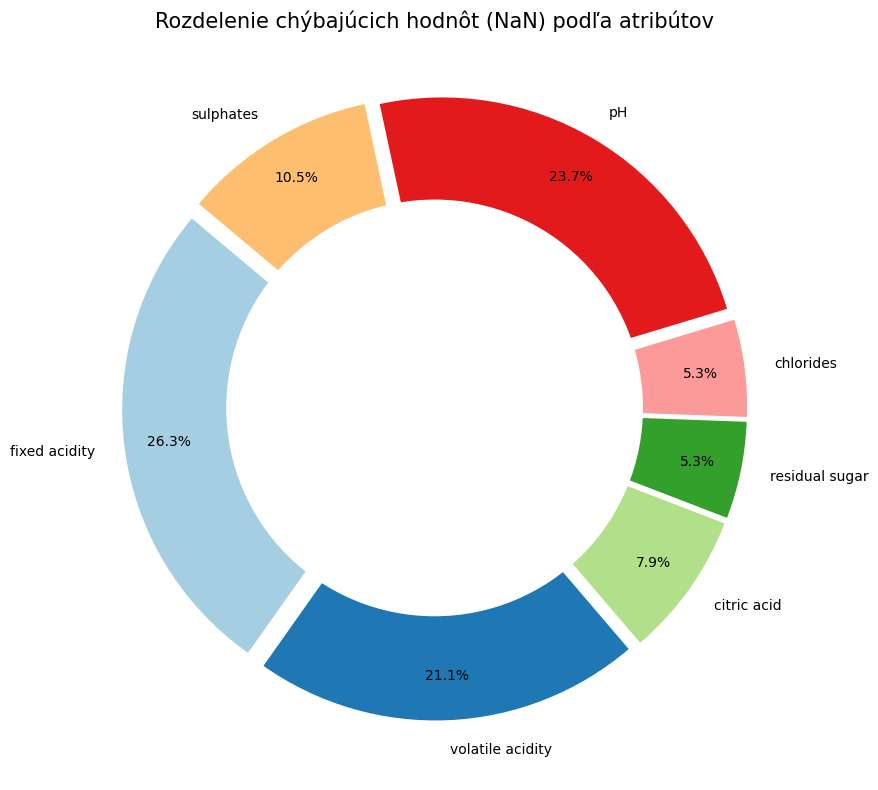

Presný počet chýbajúcich hodnôt:
fixed acidity       10
pH                   9
volatile acidity     8
sulphates            4
citric acid          3
chlorides            2
residual sugar       2
dtype: int64


In [7]:
nan_counts = df.isnull().sum()
nan_only = nan_counts[nan_counts > 0]

labels = nan_only.index
sizes = nan_only.values

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
        colors=plt.cm.Paired.colors, pctdistance=0.85, explode=[0.05]*len(nan_only))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Rozdelenie chýbajúcich hodnôt (NaN) podľa atribútov', fontsize=15)
plt.tight_layout()
plt.show()

print("Presný počet chýbajúcich hodnôt:")
print(nan_only.sort_values(ascending=False))

Na predchádzajúcej vizualizácii si môžeme povšimnúť pomery rôznych typov premenných na množine chýbajúcich hodnôt.  

Pomer týchto chýbajúcich hodnôt k celkovému počtu si môžeme ukázať následovne:

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print("Percentuálny podiel chýbajúcich hodnôt:")
for col, percent in missing_percentage.items():
    print(f"{col:<20} : {percent:.3f} %")

Percentuálny podiel chýbajúcich hodnôt:
fixed acidity        : 0.154 %
pH                   : 0.139 %
volatile acidity     : 0.123 %
sulphates            : 0.062 %
citric acid          : 0.046 %
chlorides            : 0.031 %
residual sugar       : 0.031 %


***

Tu sa nám opäť ukazuje, že chýbajucích hodnôt je príliš málo na to aby sme mohli nad nimi robiť zmysluplnú analýzu bez toho aby sme použili syntetické dáta. 

pozn: V samotnej dokumentácii datasetu je napísané, že chýbajúce hodnoty sú vytvorené umelo.  

  **"Two datasets were combined and few values were randomly removed."**  

Tento fakt nám potvrdzuje, že **rozsiahlejšia analýza chýbajúcich by nemala žiadnu pridanú hodnotu**. 
***

## Ošetrenie chýbajúcich hodnôt

S prihliadnutím na počet našich dát by sme mohli chýbajúce hodnoty vymazať.  
Tento prístup by mohol byť považovaný za radikálny a mohli by sme ním zbytočne stratiť cenné dáta.

Vzhľadom k tomu, že všetky premenné, v ktorých sa náchádzajú chýbajúce premenné, sú kvantitatívne. To znamená, že by sme ich mohli nahradiť nejakou číselnou hodnotou. Napríklad **mediánom** hodnôt danej premennej.  

pozn2: Úprimne mi poradie zadania tejto úlohy nedáva zmysel. Prečo by som mal ošetrovať a vizualizovať chýbajúce hodnoty v datasete až po prevedení vizualizácií a vypracovaní predchádzajúcich úloh. Rovnako aj s úpravou dát. Všetko sú to veci, ktoré sa robia ešte predtým ako sa začne so samotnými dátami pracovať. Preto mi aj príde mätúce to dávať do zadania až na koniec. Preto som úlohu, úprava dát a vizualizácia x ošetrenie chýbajúcich hodnôt ,spravil ešte pred samotnou prácou s nimi.

In [9]:
def fill_median(dataframe):

    df_filled = dataframe.copy()
    
    numerical = df_filled.select_dtypes(include=['number']).columns
    
    for col in numerical:
        median_value = df_filled[col].median()
        df_filled[col] = df_filled[col].fillna(median_value)
        
    return df_filled


df = fill_median(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


***
## Príprava dát  

Naše dáta nebudú potrebovať nadmierne rozsiahle úpravy.  


- Vytvoríme si premennú 'quality_label' na rozdelenie vína podľa kvality. Využijeme neskôr pri vizualizácii.  
- Taktiež si premenné s datovým typom object pretypujeme na datový typ category
- Ostatné premenné sú v číselných hodnotách

In [10]:
df['quality_label'] = df['quality'].apply(lambda x: 'Prémiové (6-9)' if x >= 6 else 'Bežné (3-5)')
df[['type', 'quality_label']] = df[['type', 'quality_label']].astype('category')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   type                  6497 non-null   category
 1   fixed acidity         6497 non-null   float64 
 2   volatile acidity      6497 non-null   float64 
 3   citric acid           6497 non-null   float64 
 4   residual sugar        6497 non-null   float64 
 5   chlorides             6497 non-null   float64 
 6   free sulfur dioxide   6497 non-null   float64 
 7   total sulfur dioxide  6497 non-null   float64 
 8   density               6497 non-null   float64 
 9   pH                    6497 non-null   float64 
 10  sulphates             6497 non-null   float64 
 11  alcohol               6497 non-null   float64 
 12  quality               6497 non-null   int64   
 13  quality_label         6497 non-null   category
dtypes: category(2), float64(11), int64(1)
memory usage: 622.

## Príznaky:




| Príznak | Popis príznaku (jednotka) |
|--------|-----------:|
| **type** | farba vína |
| **fixed acidity** | množstvo neprchavých kyselín (g/L) |
| **volatile acidity** | množstvo prchavých kyselín (g/L) |
| **citric acid** | množstvo kyseliny citrónovej (g/L) |
| **residual sugar** | množstvo zvyškového cukru (g/L) |
| **chlorides** | množstvo solí (g/L) |
| **free sulfur dioxide** | množstvo voľného oxidu siričitého (mg/L) |
| **total sulfur dioxide** | celkové množstvo oxidu siričitého (mg/L) |
| **density** | hustota (g/cm³) |
| **pH** | hodnota pH |
| **sulphates** | množstvo síranov (g/L) |
| **alcohol** | obsah alkoholu (% vol.) |
| **quality** | kvalitatívne hodnotenie (0 - 10)|  


***

Pri tejto úlohe sa budeme pomocou klasifikačných modelov snažiť o predikciu premennej '**quality**', zakódovanej do binárnej premennej '**quality type**' 

## Vizualizácia cielovej premennej

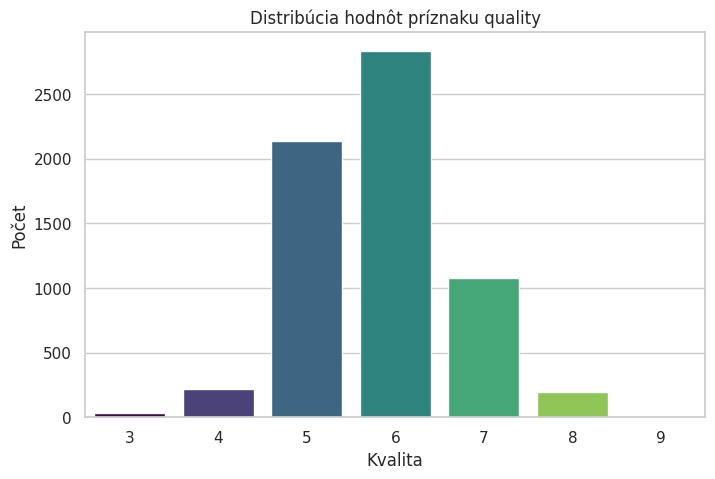

In [12]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality', hue='quality', palette='viridis', legend=False)

plt.title('Distribúcia hodnôt príznaku quality')
plt.xlabel('Kvalita')
plt.ylabel('Počet')

plt.show()

**Histogram**:  
- znázorňuje nám rozdelenie početností hodnôt premennej '**quality**'  
- môžeme si všimnúť, že naše rozdelenie je veľmi podobné **normálnemu rozdeleniu**
- najpočetnejší hodnota príznaku je hodnota '6' a najmenej početná je '9'

Pre lepšie číselné znázornenie príznaku 'quality' si ho môžeme vypísať:

In [13]:
df['quality'].value_counts()

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

## Vizualizácia premenných  

V tejto časti budeme robiť exploračnú analýzu premenných z nášho datasetu.  

In [14]:
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,Prémiové (6-9)
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,Prémiové (6-9)
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,Prémiové (6-9)
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Prémiové (6-9)
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,Prémiové (6-9)


**Má pH vplyv na množstvo neprchavých kyselín?** 

Pri prvej otázke našej analýzy sa budeme zaoberať vzťahom medzi pH a množstvom neprchavých kyselín(fixed acidity).  

Aby naša analýza mala zmysel, potrebujeme trochu nahliadnuť do chémie a zistiť, **čo vlastne hodnota pH znamená**.  

Hodnota pH nám vo veľmi zjednodušenom ponímaní hovorí, ako veľmi je roztok kyslý alebo zásaditý.  
Meria sa na mierke 0-14, kde platí následovné rozdelenie:  
- **pH < 7: Kyslé látky**  
- **pH = 7: Kyslé látky**  
- **pH > 7: Zásadité látky**  

Vzhľadom na to, že naša analýza je medzi pH a množstvom neprchavých kyselín tak môžeme predpokladať, že pH bude klesať s množstvom neprchavých kyselín.

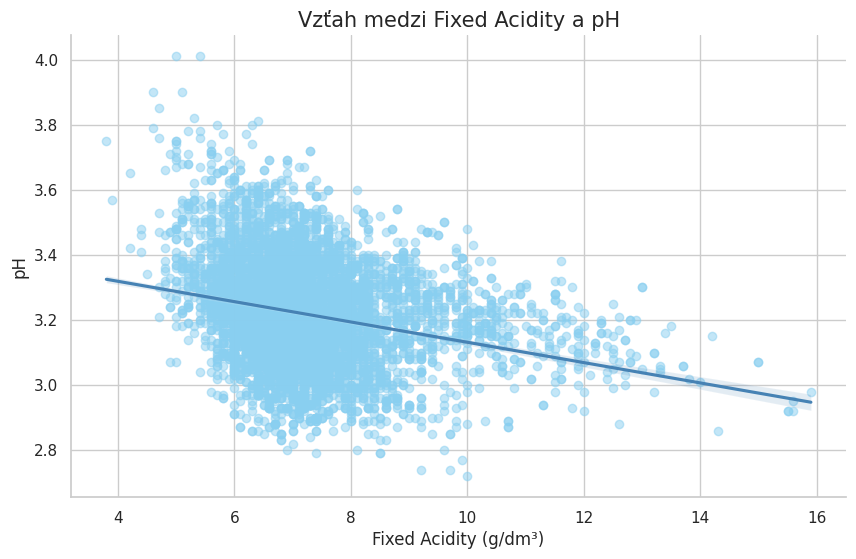

In [15]:
plt.figure(figsize=(10, 6))

sns.regplot(x='fixed acidity', y='pH', data=df, 
            scatter_kws={'alpha' : 0.5, 'color' : '#89CFF0'},
            line_kws={'color': '#4682B4'})


plt.title('Vzťah medzi Fixed Acidity a pH', fontsize=15)
plt.xlabel('Fixed Acidity (g/dm³)', fontsize=12)
plt.ylabel('pH', fontsize=12)

sns.despine()

plt.show()

Pri tejto vizualizácii sa nám náš predpoklad vzťahu medzi pH a množstvom neprchavých kyselín naplnil.  

Avšak by nás tiež mohlo zaujímať, či tieto dve premenné sú podmienené aj typom vína(biele/červené).  
V tomto prípade sa už otázkou nedokážeme zaoberať iba znalosťami, ktoré sme si pri predchádzajúcej otázke dokázali odôvodniť vedomosťami zo strednej školy.  

Pre tento prípad bude naša vizualizácia užitočnejšia a bude vizualizovať **vzťah medzi typom pH, množstvom neprchavých kyselín a typom vína**. 

<Figure size 1000x600 with 0 Axes>

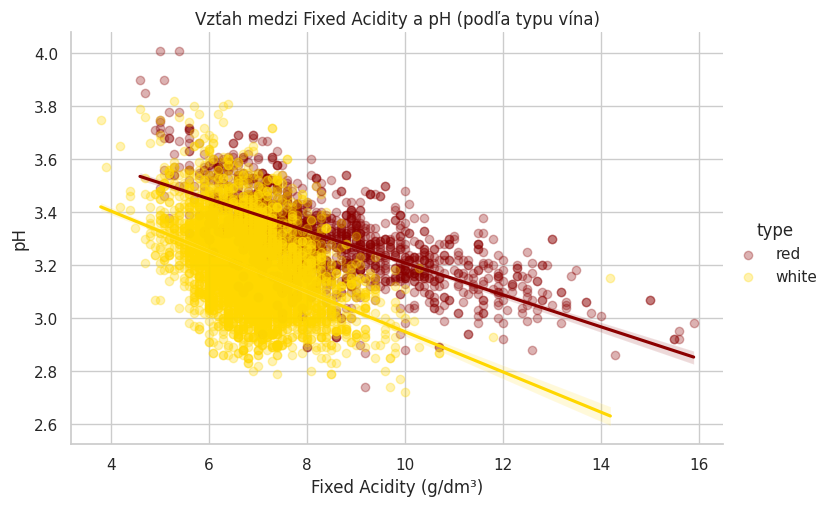

In [16]:
plt.figure(figsize=(10, 6))

sns.lmplot(x='fixed acidity', y='pH', hue='type', data=df, 
           palette={'red': 'darkred', 'white': 'gold'}, 
           scatter_kws={'alpha': 0.3}, aspect=1.5)

plt.title('Vzťah medzi Fixed Acidity a pH (podľa typu vína)')
plt.xlabel('Fixed Acidity (g/dm³)')
plt.ylabel('pH')
plt.show()

Môžeme si povšimnúť pomerne silný vzťah medzi typom vína a chemickými vlastnosťami:   
**Biele víno** -> množstvo neprchavých kyselín je viac koncentrované, značná časť sa nachádza medzi hodnotami 6-8 g/dm$^3$   
**Červené víno** -> na druhú stranu množstvo neprchavých kyselín je viac rozptýlené

To si môžeme skontrolovať aj na boxplote pre jednotlivé typy:

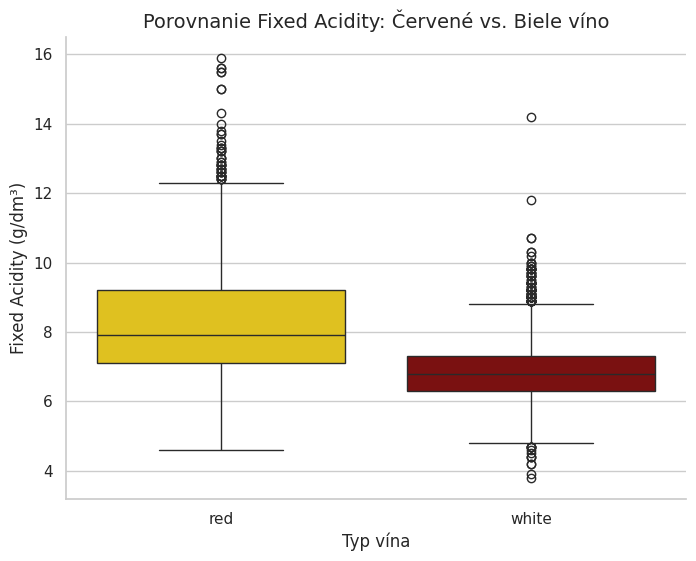

In [17]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='type', y='fixed acidity', data=df, hue='type', legend=False, palette=['gold', 'darkred']) # Baby blue odtiene pre oba boxy

plt.title('Porovnanie Fixed Acidity: Červené vs. Biele víno', fontsize=14)
plt.xlabel('Typ vína', fontsize=12)
plt.ylabel('Fixed Acidity (g/dm³)', fontsize=12)

sns.despine()

plt.show()

Na prvý pohľad by sme aj mohli usúdiť, že **pH červeného vína bude aj obecne nižšie** s rastúcim obsahom neprchavých kyselín.  
Avšak toto tvrdenie je **nepravdivé**:

In [18]:
priemery = df.groupby('type')[['fixed acidity', 'pH']].mean()

print(priemery)

       fixed acidity        pH
type                          
red         8.320450  3.310738
white       6.855768  3.188234


/tmp/ipykernel_6710/1349357339.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  priemery = df.groupby('type')[['fixed acidity', 'pH']].mean()


***


**Má vzťah množstva alkoholu na kvalitu vína?**  
 
Budeme sa snažiť zachytiť vzťah medzi obsahom alkoholu vo víne a jeho kvalitou.  

Vína sme si rozdelili na dve skupiny podľa kvality: 
**|0-5|** -> Bežné vína  
**|6-10|** -> Prémiové vína

Uvádza sa že obecne neexistuje pravidlo medzi množstvom alkoholu a kvalitou vína.  
To si môžeme potvrdiť/vyvrátiť na základe našej vizualizácie:  

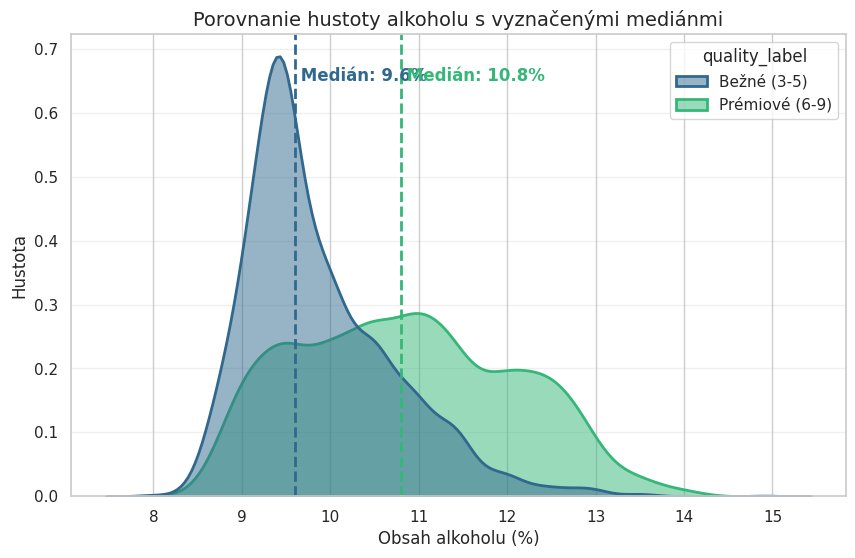

In [19]:
plt.figure(figsize=(10, 6))

ax = sns.kdeplot(data=df, x='alcohol', hue='quality_label', fill=True, 
                 common_norm=False, palette='viridis', alpha=0.5, linewidth=2)

colors = sns.color_palette('viridis', n_colors=2)

for i, label in enumerate(['Bežné (3-5)','Prémiové (6-9)']):
    median_val = df[df['quality_label'] == label]['alcohol'].median()
    
    plt.axvline(median_val, color=colors[i], linestyle='--', linewidth=2)

    plt.text(median_val, ax.get_ylim()[1] * 0.9, f' Medián: {median_val:.1f}%', 
             color=colors[i], fontweight='bold')

plt.title('Porovnanie hustoty alkoholu s vyznačenými mediánmi', fontsize=14)
plt.xlabel('Obsah alkoholu (%)', fontsize=12)
plt.ylabel('Hustota', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

Z našej vizualizácie vieme spraviť následujúce pozorovania:  
1. Bežné vína majú tendenciu mať nižší obsah alkoholu ako obvyklé tie prémiové
2. Prémiové vína majú vačší rozptyl obsahu alkoholu ako tie bežné
3. Môžeme si povšmnúť výrazný nárast počtu bežných vín pri obsahu alkoholu okolo 9,5%.
   - môže to naznačovať prípadný štandard obsahu alkoholu menej kvalitných vín
***

## Úprava dát pre strojové učenie

Na začiatku vypracovávania úlohy sme si vytvorili dataframe learn_df, na ktorý sme si skopírovali náš dataset.  
Tento dataset upravíme tak aby bol vhodný na použitie pri strojovom učení.  

Na použitie dát pri strojovom učení potrebujem vytvoriť z našich dát číselnú maticu.

In [20]:
learn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


Vidíme, že takmer všetky premenné nám predstavujú číselné hodnoty.  

Budeme ešte musieť správne zakódovať premennú 'type' a nejako rozumne reprezentovať chýbajúce hodnoty.   
Aby sme sa vyvarovali úniku dát(leakage) najprv pred samotnými úpravami rozdelíme množinu na **trénovaciu, validačnú a testovaciu**. 

In [21]:
#pretypovali sme premennú type z 'object' na 'type'
learn_df['type'] = df['type'].astype('category')
learn_df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Tieto množiny budeme reprezentovať pomocou dataframes -> jednoduchšia aplikácia úprav.  

Naše modely budú založené na binárnej klasifikácii. Podľa toho si upravíme našu cieľovú premennú 'quality' na premennú 'quality type', ktorá nám bude rozdelovať vína podľa kvality na **Bežné(0-5) -> 0** a **Prémiové(6-10) -> 1**

In [22]:
#random seed na generovanie rovnakých množín
random_seed = 123


learn_df['quality type'] = (learn_df['quality'] >= 6).astype(int)
learn_df.drop(columns=['quality'], inplace=True)


target_col = 'quality type'

train_df, temp_df = train_test_split(
    learn_df, test_size=0.4, random_state=random_seed, stratify=learn_df[target_col]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=random_seed, stratify=temp_df[target_col]
)

Vytvoríme si dve funkcie:
1. **get_median** -> touto funkciou získame medián premennej
2. **input_median** -> vložíme medián premennej na miesto chýbajúcej hodnoty

In [23]:
def get_median(train_df, col):
    return train_df[col].median()


In [24]:
def input_median(df, med_value, col):
    df_copy = df.copy()
    df_copy[col] = df_copy[col].fillna(med_value)
    return df_copy

Aplikácia funkcii na premenné, ktorým chýbajú hodnoty:

In [25]:
cols_with_missing = ['fixed acidity', 'volatile acidity', 'citric acid', 
                     'residual sugar', 'chlorides', 'pH', 'sulphates']

train_median = get_median(train_df, col)

for col in cols_with_missing:
    train_df = input_median(train_df, train_median, col)
    val_df = input_median(test_df, train_median, col)
    test_df = input_median(test_df, train_median, col)

In [26]:
#overenie, že všetky dataframes majú všetky hodnoty -> naše funkcie prebehli úspešne

print(train_df.isnull().any())
print(val_df.isnull().any())
print(test_df.isnull().any())

type                    False
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality type            False
dtype: bool
type                    False
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur dioxide     False
total sulfur dioxide    False
density                 False
pH                      False
sulphates               False
alcohol                 False
quality type            False
dtype: bool
type                    False
fixed acidity           False
volatile acidity        False
citric acid             False
residual sugar          False
chlorides               False
free sulfur diox

In [27]:
train_df = pd.get_dummies(train_df, columns=['type'], drop_first=True)
expected_columns = train_df.columns

Nominálnu premennú 'type' sme zakódovali pomocou one-hot. Zistili sme možné hodnoty zakódovania stĺpcov na trénovaceje množine a túto informáciu sme potom aplikovali aj na validačnú a testovaciu množinu.

In [28]:
test_df = pd.get_dummies(test_df, columns=['type'], drop_first=True)
test_df = test_df.reindex(columns=expected_columns, fill_value=0)

val_df = pd.get_dummies(val_df, columns=['type'], drop_first=True)
val_df = val_df.reindex(columns=expected_columns, fill_value=0)

In [29]:
train_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality type,type_white
4497,6.3,0.29,0.30,8.1,0.212,60.0,150.0,0.99580,3.10,0.40,9.3,0,True
4995,7.0,0.50,0.25,2.0,0.070,3.0,22.0,0.99630,3.25,0.63,9.2,0,False
2535,9.0,0.26,0.34,6.7,0.029,21.0,162.0,0.99497,3.08,0.50,10.6,1,True
4180,6.5,0.31,0.61,13.0,0.053,31.0,123.0,0.99708,3.09,0.50,9.3,1,True
789,7.6,0.30,0.27,10.6,0.039,31.0,119.0,0.99815,3.27,0.30,9.3,1,True


Dosadenie naších dataframes do matíc, ktoré budú využité pri trénovaní modelov:

In [30]:
Xtrain = train_df.drop(columns=[target_col]).copy()
ytrain = train_df[target_col].copy()

Xval = val_df.drop(columns=[target_col]).copy()
yval = val_df[target_col].copy()

Xtest = test_df.drop(columns=[target_col]).copy()
ytest = test_df[target_col].copy()

Ešte pred samotným využitím modelov by som sa pozrel na počty hodnôt premennej 'quality type' v našom datasete.

In [31]:
learn_df['quality type'].value_counts()

quality type
1    4113
0    2384
Name: count, dtype: int64

Tu môžeme usúdiť, že podľa počtov Bežného(0) a Prémiového(1) vína, bude predikcia Prémiového vína o niečo presnejšia.  
Môžeme pozorovať nevyváženosť tried.

## Voľba modelov

Na vyhodnocovanie našich predpripravených dát sme si vybrali modely strojového učenia násedovne:
1. **kNN - k-Nearest Neighbors** -> jednoduchší modelu pre binárnu klasifikáciu, funguje na princípe porovnania s podobnými prvkami z datasetu
2. **Random Forest - náhodný les** ->  ensemble metóda, ktorá funguje na princípe spájania viacerých rozhodovacích stromov

***

## Voľba evaluačnej metriky

Na vyhodnocovanie budeem používať dve evaluačné metriky:
1. **accuracy_score** -> metrika, ktorá nám vyjadruje celkovú úspešnosť modelu
   - 1 -> 100% úspešnosť (model je perfektný)
   - 0.5 -> 50% úspešnosť (model pri binárnej klasifikácii má presnosť ako "náhodný odhad")
     ***

   
     
3. **AUC** -> metrika, ktorá nám vyjadruje plochu pod ROC krivkou
   - ROC krivka vyjadruje grafický vzťah medzi schopnosťou modelu identifikovať skutočne pozitívne prípady (citlivosť) a mierou jeho omylov pri falošných poplachoch (falošná pozitivita) pri rôznych prahových hodnotách klasifikácie.
   - index kvality modelu je veľmi podobný ako pri accuracy_score


***
## Základné trénovanie modelov



**kNN**  

Pri základnom trénovaní kNN modelu sme použili hyperparameter n_neighbors = 5 -> model bude vyhodnocovať výsledok podľa 5 najpodobnejších prípadov.

In [32]:
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(Xtrain, ytrain)


y_pred_knn = clf.predict(Xval)
y_probs_knn = clf.predict_proba(Xval)[:, 1]

fpr_knn, tpr_knn, thresholds = roc_curve(yval, y_probs_knn)

auc_value = roc_auc_score(yval, y_probs_knn)
acc = accuracy_score(yval, y_pred_knn)
print(f"Accuracy score: {acc:.2%}")

print(f"AUC: {auc_value:.4f}")

Accuracy score: 64.62%
AUC: 0.6731


Podľa celkovej úspešnosti modelu a AUC metriky vieme o modeli usúdiť, že je podstatne lepší, ako náhodný výber ale ako predikčný model má veľmi nízku úspešnosť.
***
Ako prvú vizualizáciu kvality modelu sme využili **Confusion Matrix**  

Tá nám zobrazuje, ako bol náš model úspešný pri rozoznávaní správnych a nesprávnych prípadov:

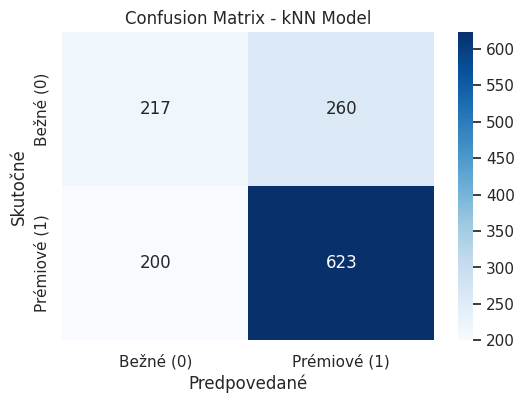

In [33]:
cm = confusion_matrix(yval, y_pred_knn)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bežné (0)', 'Prémiové (1)'], 
            yticklabels=['Bežné (0)', 'Prémiové (1)'])
plt.xlabel('Predpovedané')
plt.ylabel('Skutočné')
plt.title('Confusion Matrix - kNN Model')
plt.show()

Môžeme si všimnúť, že náš model je relatívne dobrý pri odhade Prémiového vína ale o značnú časť horší pri odhade Bežného vína. Dokonca do takej miery, že je väčšia šanca, že zle odhadne Prémiové víno, ako keby mal správne odhadnúť to Bežné.  
***
Ako sme vyššie spomenuli, **ROC krivka** vyjadruje grafický vzťah medzi schopnosťou modelu identifikovať skutočne pozitívne prípady (citlivosť) a mierou jeho omylov pri falošných poplachoch (falošná pozitivita) pri rôznych prahových hodnotách klasifikácie.

Vizualizácia tejto krivky vyzerá následovne:


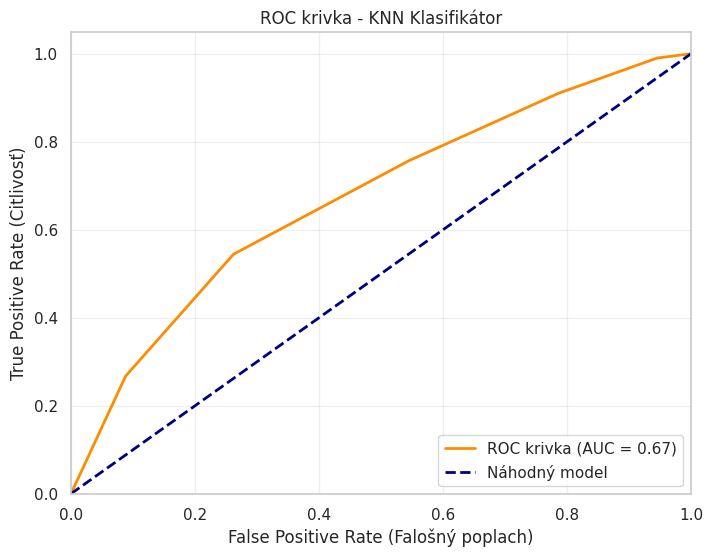

In [34]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label=f'ROC krivka (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Náhodný model')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falošný poplach)')
plt.ylabel('True Positive Rate (Citlivosť)')
plt.title('ROC krivka - KNN Klasifikátor')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

**Random Forest**  

Pri základnom trénovaní modelu Random Forest sme použili hyperparameter n_estimators = 100 -> model bude vyhodnocovať výsledok podľa 100 menších rozhodovacích stromov.

In [35]:
rf_clf = RandomForestClassifier(n_estimators=100, random_state=random_seed)
rf_clf.fit(Xtrain, ytrain)

y_pred_rf = rf_clf.predict(Xval)
y_probs_rf = rf_clf.predict_proba(Xval)[:, 1]

print(f"Accuracy score: {accuracy_score(yval, y_pred_rf):.2f}%")
print(f"AUC: {roc_auc_score(yval, y_probs_rf):.4f}")


Accuracy score: 0.84%
AUC: 0.9085


Na vyhodnocovacích metrikách môžeme už na prvý pohľad povedať, že tento model je omnoho vhodnejší na klasifikačné úlohy, kde nás nezaujíma dĺžka výpočtu.
***
**Confusion Matrix**

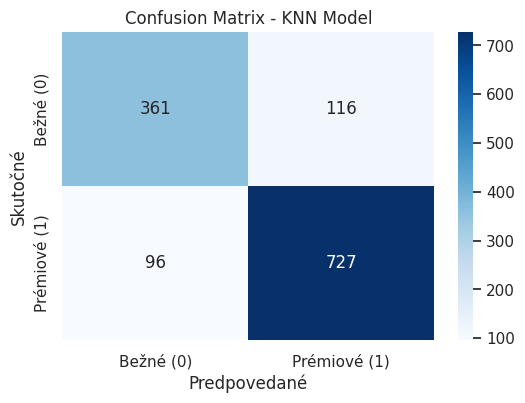

In [36]:
cm = confusion_matrix(yval, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bežné (0)', 'Prémiové (1)'], 
            yticklabels=['Bežné (0)', 'Prémiové (1)'])
plt.xlabel('Predpovedané')
plt.ylabel('Skutočné')
plt.title('Confusion Matrix - KNN Model')
plt.show()

Pri **Confusion Matrix** sme tiež zistili, že model je veľmi dobrý vo vyhodnocovaní ako aj Prémiových vín tak aj Bežných vín.  
***
**ROC krivka**

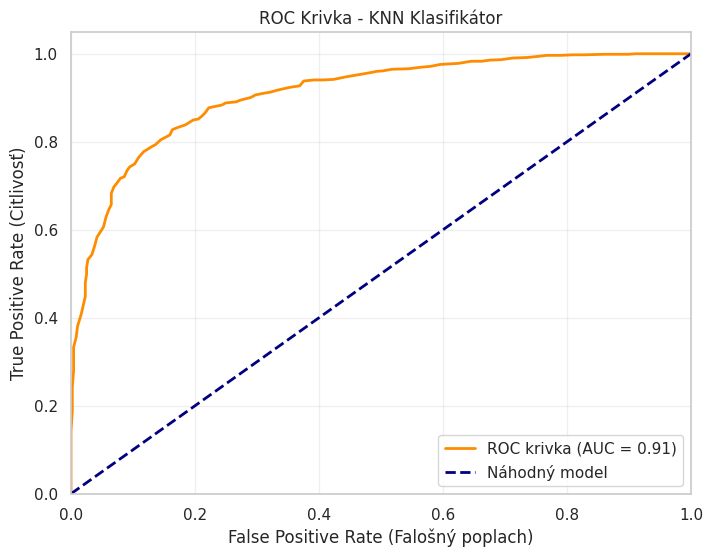

Plocha pod krivkou (AUC): 0.9085


In [37]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(yval, y_probs_rf)

auc_rf = roc_auc_score(yval, y_probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f'ROC krivka (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Náhodný model')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falošný poplach)')
plt.ylabel('True Positive Rate (Citlivosť)')
plt.title('ROC Krivka - KNN Klasifikátor')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Plocha pod krivkou (AUC): {auc_rf:.4f}")

***
**Dôležitosť premenných**

Pri modeli RandomForest dokážeme zo spôsobu akým tento model funguje, zistiť dôležitosť jednotlivých premenných.  

Tento fakt je zachytený v mierke relatívnej dôležitosti:  

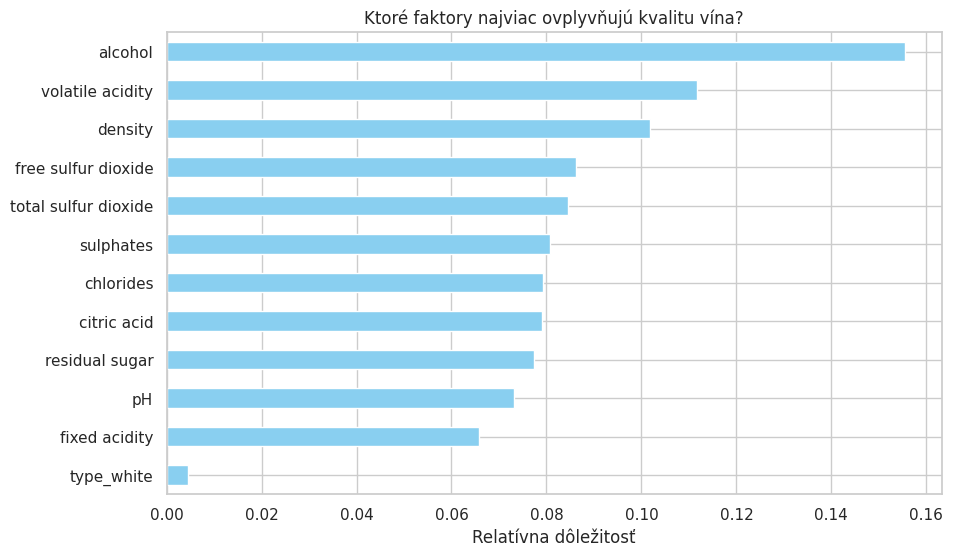

In [38]:
importances = pd.Series(rf_clf.feature_importances_, index=Xtrain.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#89CFF0')
plt.title('Ktoré faktory najviac ovplyvňujú kvalitu vína?')
plt.xlabel('Relatívna dôležitosť')
plt.show()

Z tejto mierky dokážeme napríklad vyčítať, že pre náš model RandomForest bol najväčší vplyv na ohodnotenie vína mal alkohol a najmenší vplyv mal typ vína.

Dôležitosť týchto premenných sa správa lineárne, čiže alkohol mal približne dvojnásobnú dôležitosť ako množstvo síranov vo víne.
***

# Ladění modelu - Random Forest

* Ladění modelu RandomForest pro binární klasifikaci proměnné quality type. Hledání nejlepší kombinace hyperparametrů a hodnocení výkonnosti na validační množině.

## Zvolený model
**RandomForestClassifier**

## Zvolené hyperparametry
* n_estimators
  * Více stromů obvykle snižuje variance a stabilizuje výsledky. Běh ale trvá déle.
* max_depth
  * Omezuje složitost jednotlivých stromů, malé hodnoty mohou způsobit underfitting, velmi velké hodnoty mohou vést k overfittingu.


Samotné podmodely RandomForest se většinou označují jako takzvané weak learners, tedy sami o sobě nejsou silnými modely, ale dohromady při použítí metody Baggingu tvoří dobrý výsledný model. To je typické pro většinu Ensemble modelů.

* Modely se trénují na trénovací množině (Xtrain, ytrain) a hodnocení každé kombinace je prováděno na validační množině (Xval, yval) pomocí AUC i accuracy.

Dataset vykazuje nevyváženost tříd. Proto při trénování použijeme parametr class_weight='balanced', který automaticky upraví váhy tříd nepřímo úměrně k jejich frekvenci. 

In [43]:
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score

In [66]:
n_estimators = [25, 75, 125, 150, 200, 225, 250]
max_depths = [3, 5, 8, 15, 20, 25, 30]
results = []
best_auc = 0
best_params = {}

In [67]:
for n in n_estimators:
    for d in max_depths:
        clf = RandomForestClassifier(n_estimators=n, max_depth=d, class_weight='balanced', random_state=random_seed)
        clf.fit(Xtrain, ytrain)
        probs_val = clf.predict_proba(Xval)[:,1]
        preds_val = clf.predict(Xval)
        auc = roc_auc_score(yval, probs_val)
        acc = accuracy_score(yval, preds_val)
        results.append({'n_estimators': n, 'max_depth': d, 'auc': auc, 'accuracy': acc})

In [68]:
# Převod výsledků na DataFrame pro jednodušší vizualizaci
result_df = pd.DataFrame(results)
display(result_df.head())
result_df.info()

,n_estimators,max_depth,auc,accuracy
0,25,3,0.813518,0.748462
1,25,5,0.835585,0.760000
2,25,8,0.863720,0.790769
3,25,15,0.896997,0.829231
4,25,20,0.899151,0.826923


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   n_estimators  49 non-null     int64  
 1   max_depth     49 non-null     int64  
 2   auc           49 non-null     float64
 3   accuracy      49 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 1.7 KB


In [75]:
acc_best = result_df.loc[result_df['accuracy'].idxmax()]
auc_best = result_df.loc[result_df['auc'].idxmax()]

print("Best Parameters and result for accuracy on validation:\n",acc_best)
print("--"*50)
print("Best Parameters and result for AUC on validation:\n",auc_best)

Best Parameters and result for accuracy on validation:
 n_estimators    225.000000
max_depth        25.000000
auc               0.912490
accuracy          0.840769
Name: 40, dtype: float64
----------------------------------------------------------------------------------------------------
Best Parameters and result for AUC on validation:
 n_estimators    225.000000
max_depth        25.000000
auc               0.912490
accuracy          0.840769
Name: 40, dtype: float64


* Vidíme, že nejlepší hyperparametry pro nejlepší hodnotu AUC i accuracy jsou stejné.

# Vizualizace vlivu hyperparametrů

Vztah mezi počtem stromů, jejich hloubkou a kvalitou modelu získáme vizualizací pomocí Heatmap. Sledujeme metriku AUC, protože je robustnější vůči nevyváženým třídám.

* pivot
  * Na jednu osu dá Počet stromů.
  * Na druhou osu dá Hloubku
  * Dovnitř tabulky dal výsledné skóre (AUC)

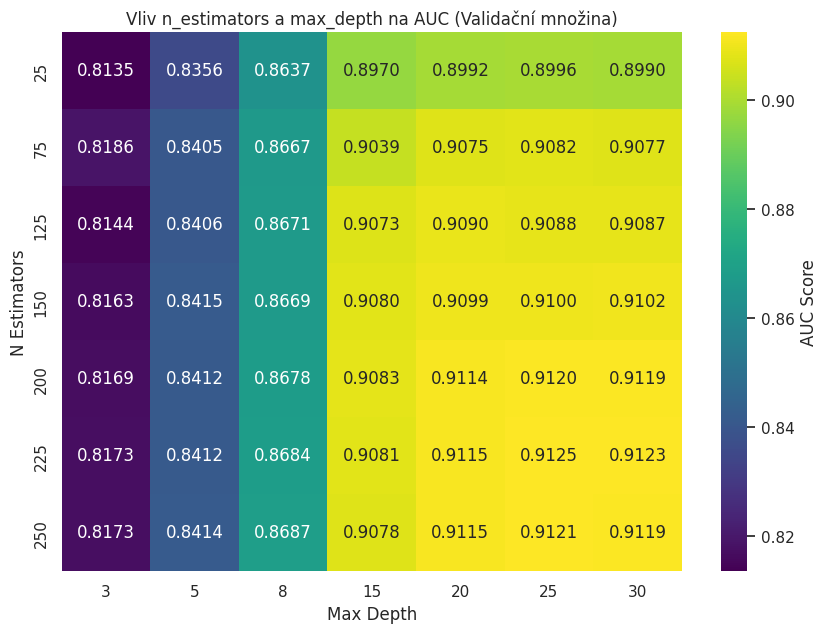

In [78]:
pivot_table_auc = result_df.pivot(index='n_estimators', columns='max_depth', values='auc')

plt.figure(figsize=(10, 7))
sns.heatmap(pivot_table_auc, annot=True, fmt=".4f", cmap='viridis', cbar_kws={'label': 'AUC Score'})

plt.title('Vliv n_estimators a max_depth na AUC (Validační množina)')
plt.xlabel('Max Depth')
plt.ylabel('N Estimators')
plt.show()

## Komentář k vizualizaci ladění
### Z Heatmapy můžeme pozorovat chování modelu:
* Vidíme, že při nízkých hodnotách hloubky je výkon modelu nižší. Kolem hodnoty 25 se stabilizuje a pro hodnotu 30 už lehce klesá.
* Změna výkonosti při změně počtu stromů není příliš znatelná. Hodnoty se pohybují v malém rozmezí.
* Heatmapa nám ukazuje oblast s nejsvětlejší barvou (nejvyšší AUC).

# Vizualizace architektury
Vizualizovat celý Random Forest (stovky stromů) najednou není technicky čitelné. Pro ilustraci architektury však můžeme extrahovat a vykreslit jeden konkrétní rozhodovací strom. Omezení hloubky pro vykreslení, aby byl diagram čitelný.

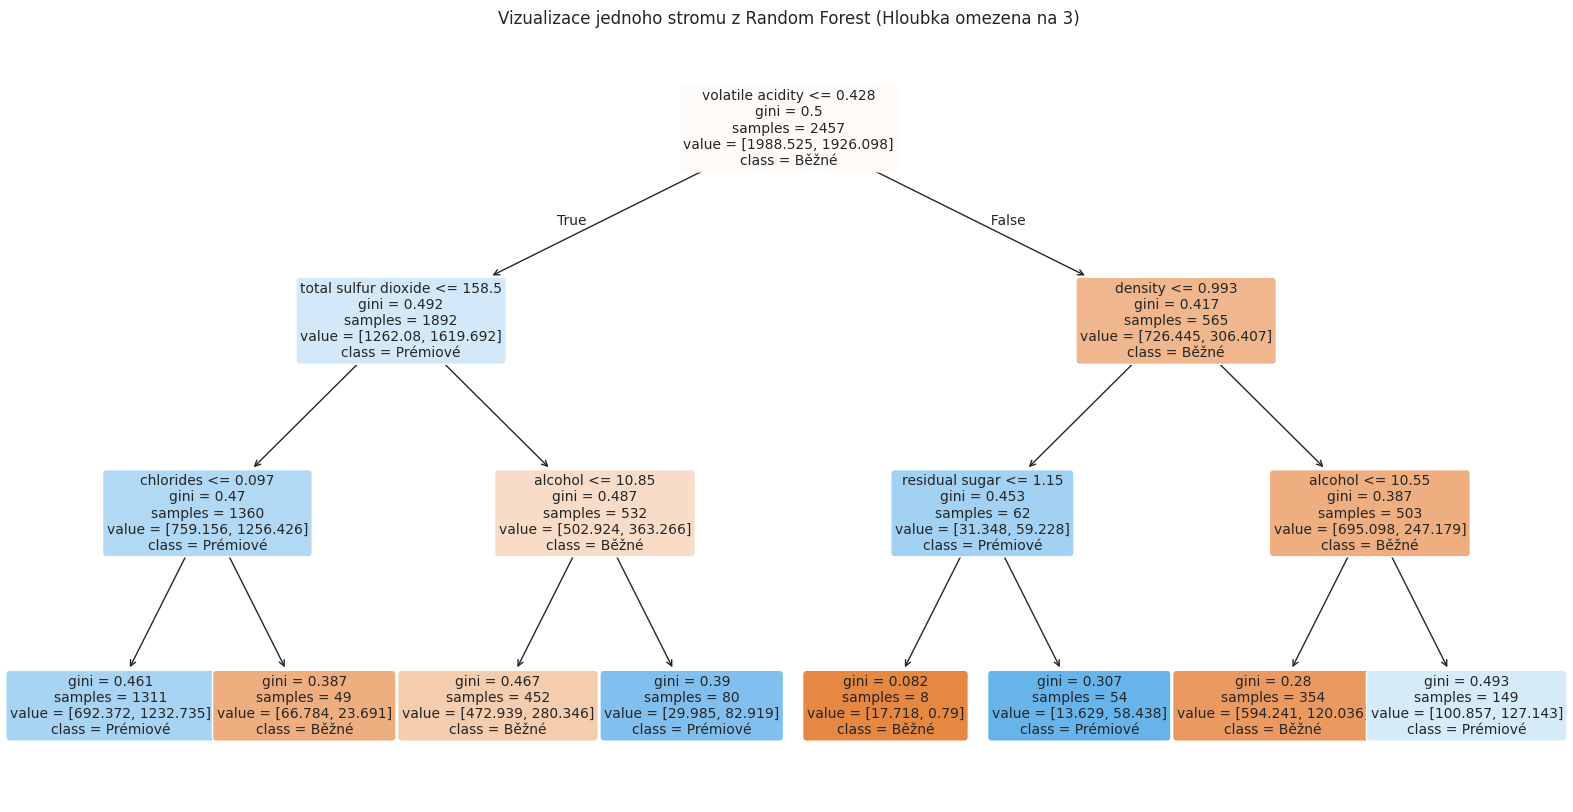

In [85]:
from sklearn.tree import plot_tree
clf = RandomForestClassifier(n_estimators=int(acc_best['n_estimators']), max_depth=3,
                            class_weight='balanced', random_state=random_seed)
clf.fit(Xtrain, ytrain)

#První strom
plt.figure(figsize=(20, 10))
plot_tree(clf.estimators_[0], 
          feature_names=Xtrain.columns, 
          class_names=['Běžné', 'Prémiové'], 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title('Vizualizace jednoho stromu z Random Forest (Hloubka omezena na 3)')
plt.show()

* Na tomto diagramu vidíme hierarchickou strukturu rozhodování. Neladili jsme hyperparametr criterion. Je vidět, že se použil defaultní Gini index. Duhou variantou by mohla být ještě entropie.
* U vrcholů stromů jsou jasně vyznačené i třídy rozdělení (Prémiové/běžné).
* Barva uzlu indikuje dominující třídu (oranžová pro Běžné, modrá pro Prémiové). 

# Vizualizace chování výsledného modelu
* Máme nalzené nejlepší hypermarametry, natrénujeme finální model a jeho úspěost ověříme na testovací množině.
* Toto nám dá reálný obraz jeho výkonosti.

In [87]:
clf = RandomForestClassifier(n_estimators=int(acc_best['n_estimators']), max_depth=int(acc_best['max_depth']),
                            class_weight='balanced', random_state=random_seed)
clf.fit(Xtrain, ytrain)
y_pred_test = clf.predict(Xtest)
y_probs_test = clf.predict_proba(Xtest)[:, 1]

print("Výsledky na testovací množině:")
print(f"Accuracy: {accuracy_score(ytest, y_pred_test):.2%}")
print(f"AUC: {roc_auc_score(ytest, y_probs_test):.4f}")
print("\nClassification Report:")
print(classification_report(ytest, y_pred_test, target_names=['Běžné (0)', 'Prémiové (1)']))

Výsledky na testovací množině:
Accuracy: 84.08%
AUC: 0.9125

Classification Report:
              precision    recall  f1-score   support

   Běžné (0)       0.80      0.76      0.78       477
Prémiové (1)       0.86      0.89      0.88       823

    accuracy                           0.84      1300
   macro avg       0.83      0.82      0.83      1300
weighted avg       0.84      0.84      0.84      1300



### Pro detailní analýzu chyb a chování modelu lze oužít 2 vizualizační metody: Confusion Matrix a ROC křivku.

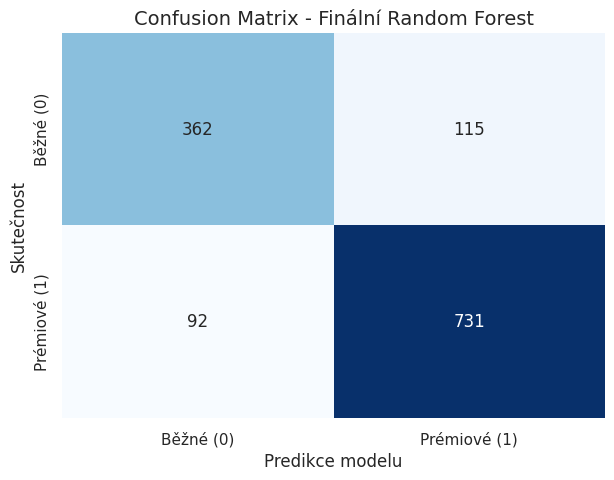

In [88]:
cm_final = confusion_matrix(ytest, y_pred_test)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Běžné (0)', 'Prémiové (1)'], 
            yticklabels=['Běžné (0)', 'Prémiové (1)'],
            cbar=False)

plt.xlabel('Predikce modelu', fontsize=12)
plt.ylabel('Skutečnost', fontsize=12)
plt.title('Confusion Matrix - Finální Random Forest', fontsize=14)
plt.show()

* True Negatives (Nahoře vlevo): Model správně identifikoval většinu běžných vín.
* True Positives (Dole vpravo): Model správně zachytil vysoký počet prémiových vín.
* False Positives (Nahoře vpravo): Počet chybných predikcí je poměrně vysoký.
* False Negatives (Dole vlevo): Tato hodnota se také blíží k hodnotě 100 a není ideální.

### ROC Křivka a distribuce pravděpodobností

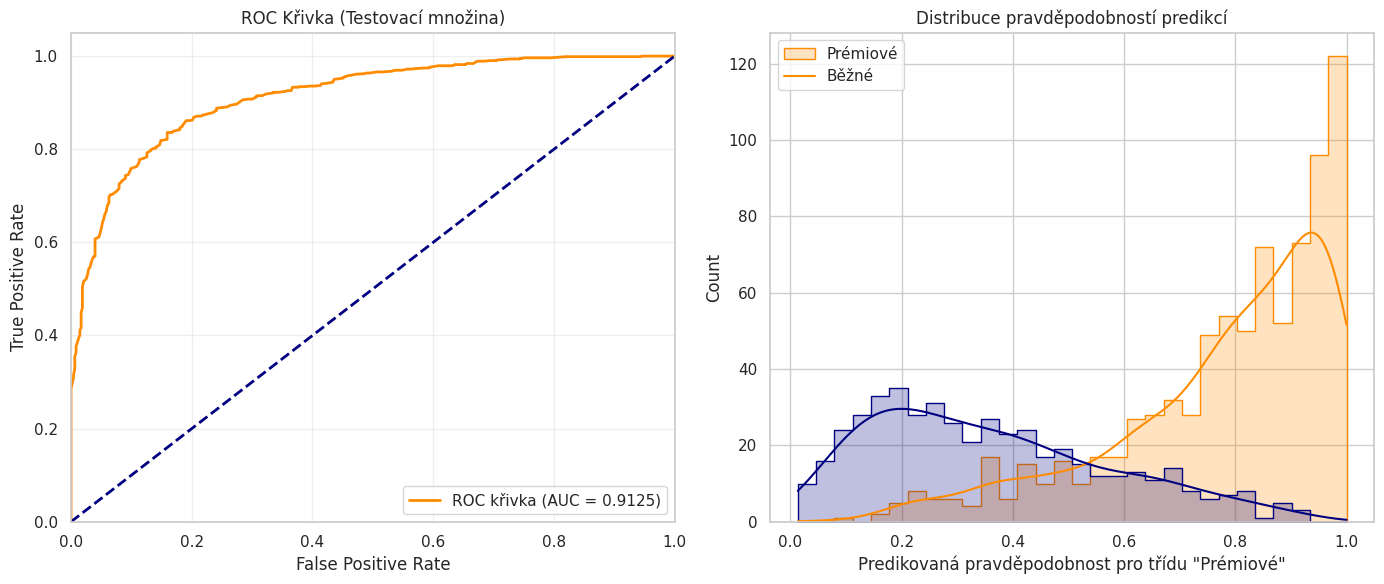

In [89]:
fpr_final, tpr_final, _ = roc_curve(ytest, y_probs_test)
auc_final = roc_auc_score(ytest, y_probs_test)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(fpr_final, tpr_final, color='darkorange', lw=2, label=f'ROC křivka (AUC = {auc_final:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Křivka (Testovací množina)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(x=y_probs_test, hue=ytest, bins=30, kde=True, palette={0: 'navy', 1: 'darkorange'}, element="step")
plt.xlabel('Predikovaná pravděpodobnost pro třídu "Prémiové"')
plt.title('Distribuce pravděpodobností predikcí')
plt.legend(labels=['Prémiové', 'Běžné'])

plt.tight_layout()
plt.show()

### Interpretace
* ROC křivka:
  *  Křivka se prudce zvedá k levému hornímu rohu, což indikuje výbornou schopnost modelu rozlišovat mezi třídami. Hodnota AUC přibližne 0.91 na testovacích datech potvrzuje, že model je robustní a nebyl přeučen.
* Distribuce pravděpodobností
  * S jakou jistotou model přiřazuje třídy.
  * Překryv ve středu naznačuje místa, kde si model není jistý. Toto jsou pravděpodobně hraniční vína (např. kvalita 5 nebo 6).

## Důležitost příznaků

* Jak jednotlivé vstupní proměnné souvisejí s cílovou proměnou bez ohledu na použitý model.

Pro zkoumání korelace vstupních příznaků můžeme použít 2 různé korelační koeficienty.
### 1. Pearsonův korelační koeficient
* Měří sílu lineární závislosti.
* Snaží se proložit daty lineární přímku.
* Je velmi citlivý na odlehlé hodnoty a neumí dobe zachytit zakřivené vztahy.

### 2. Spearmanův korelační koeficient
* Měří sílu monotónního vztahu.
* Nepočítá se skutečnými hodnotami, ale s jejich pořadím.
* Je robustní vůči odlehlým hodnotám a zachytí i nelineární vztahy.

In [91]:
correlations = pd.DataFrame()

correlations['Pearson'] = train_df.corr(method='pearson')['quality type']
correlations['Spearman'] = train_df.corr(method='spearman')['quality type']

# odstranění cílové hodnoty (korelace sama se sebou vyjde 1)
correlations = correlations.drop('quality type')

correlations = correlations.sort_values(by='Spearman', key=abs, ascending=True)

<Figure size 1200x800 with 0 Axes>

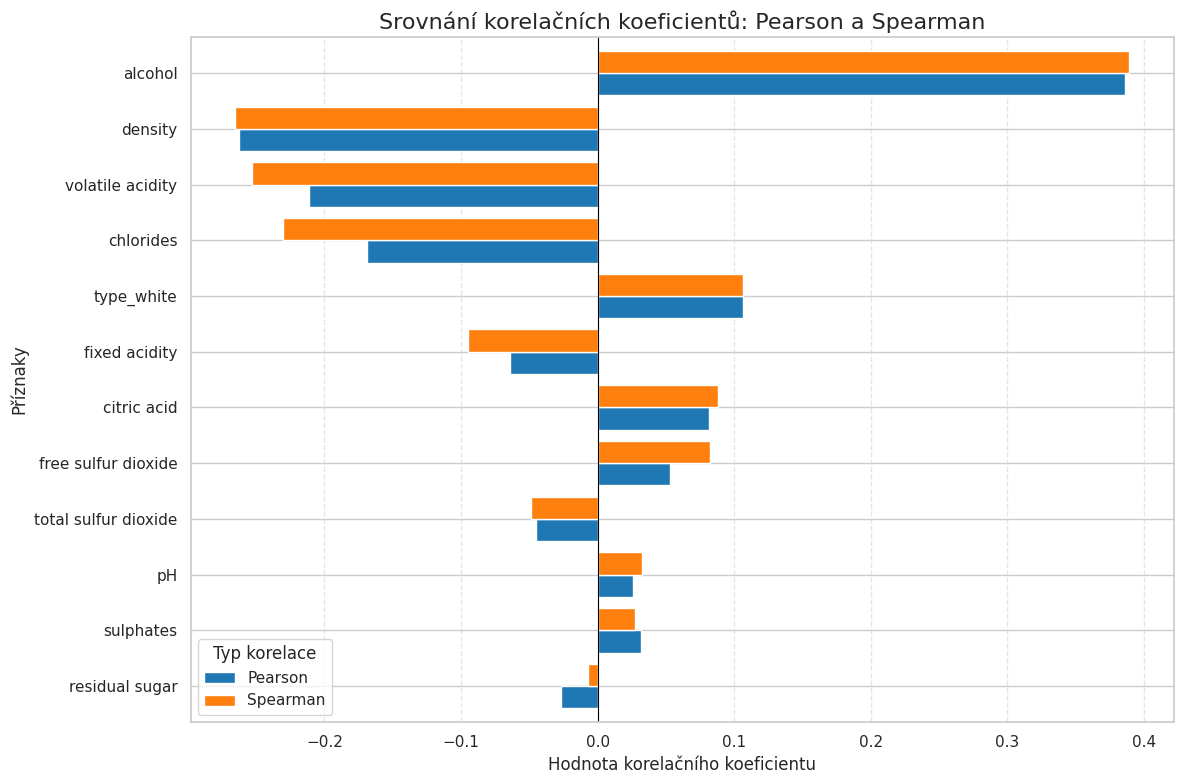

In [93]:
plt.figure(figsize=(12, 8))

# grouped bar chart
correlations.plot(kind='barh', figsize=(12, 8), color=['#1f77b4', '#ff7f0e'], width=0.8)

plt.title('Srovnání korelačních koeficientů: Pearson a Spearman', fontsize=16)
plt.xlabel('Hodnota korelačního koeficientu', fontsize=12)
plt.ylabel('Příznaky', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Typ korelace')

plt.tight_layout()
plt.show()

## Interpretace

* Čím delší pruh (na jakoukoli stranu), tím silnější je vztah s kvalitou vína.
* Směr:
  * Po směru doprava s rostoucí hodnotou příznaku roste šance, že víno je prémiové. Z grafu je vidět, že například pro alcohol nebo type_white.
  * Po směru doleva S rostoucí hodnotou příznaku kvalita klesá. Z grafu je vidět, že například pro density nebo voladite_acidity.

##### Porovnání koeficientů
* Z grafu je vidět, že hodnoty jsou si velice podobné u většiny příznaků. Z toho vyplývá, že vztah je pravděpodobně čistě lineární. Změna v příznakách přímo úměrně mění kvalitu.
* Přestože jsou rozdíly malé u většiny příznaků je Spearmanm koeficiten větší. 
* Tam kde je větší Spearmanm, tak vztah existuje, ale není lineární.

### Celkové pozorování
Korelace příznaků a vysvětlované proměnné se pohybuje u nízkých hodnot v rozmezí od -0.2 do 0.4. Kde největší korelační závislost je pro tyto 4 příznaky: alcohol, density, voladite_acidity a chlorides.

## Globální metody
Zvolené metody:
* Feature Importances
* Permutation Importance

#### 1. Feature Importances
* Tato metoda je specifická nejen pro stromové algoritmy. Je k dispozici ihned po natrénování. Má tendenci nadhodnocovat příznaky, které mají hodně unikátních hodnot. Počítá se na trénovacích datech, takže může odrážet i to, jak se model přeučil.

#### 2. Permutation Importances
* Měří skutečný pokles výkonu na datech, která model neviděl (testovací množina). Hodnota nám přímo říká o kolik procent se zhorší model bez tohoto příznaku. Časově náročnější, musí se provádět opakovaně pro každý příznak.

In [97]:
from sklearn.inspection import permutation_importance

mdi_importances = pd.Series(clf.feature_importances_, index=Xtrain.columns).sort_values(ascending=True)

# Počítáno na testovacích datech, aby byla vidět generalizace
perm_result = permutation_importance(
    clf, Xtest, ytest, 
    n_repeats=10, 
    random_state=random_seed, 
    scoring='roc_auc' # zvolená metrika je AUC
)
sorted_idx = perm_result.importances_mean.argsort()


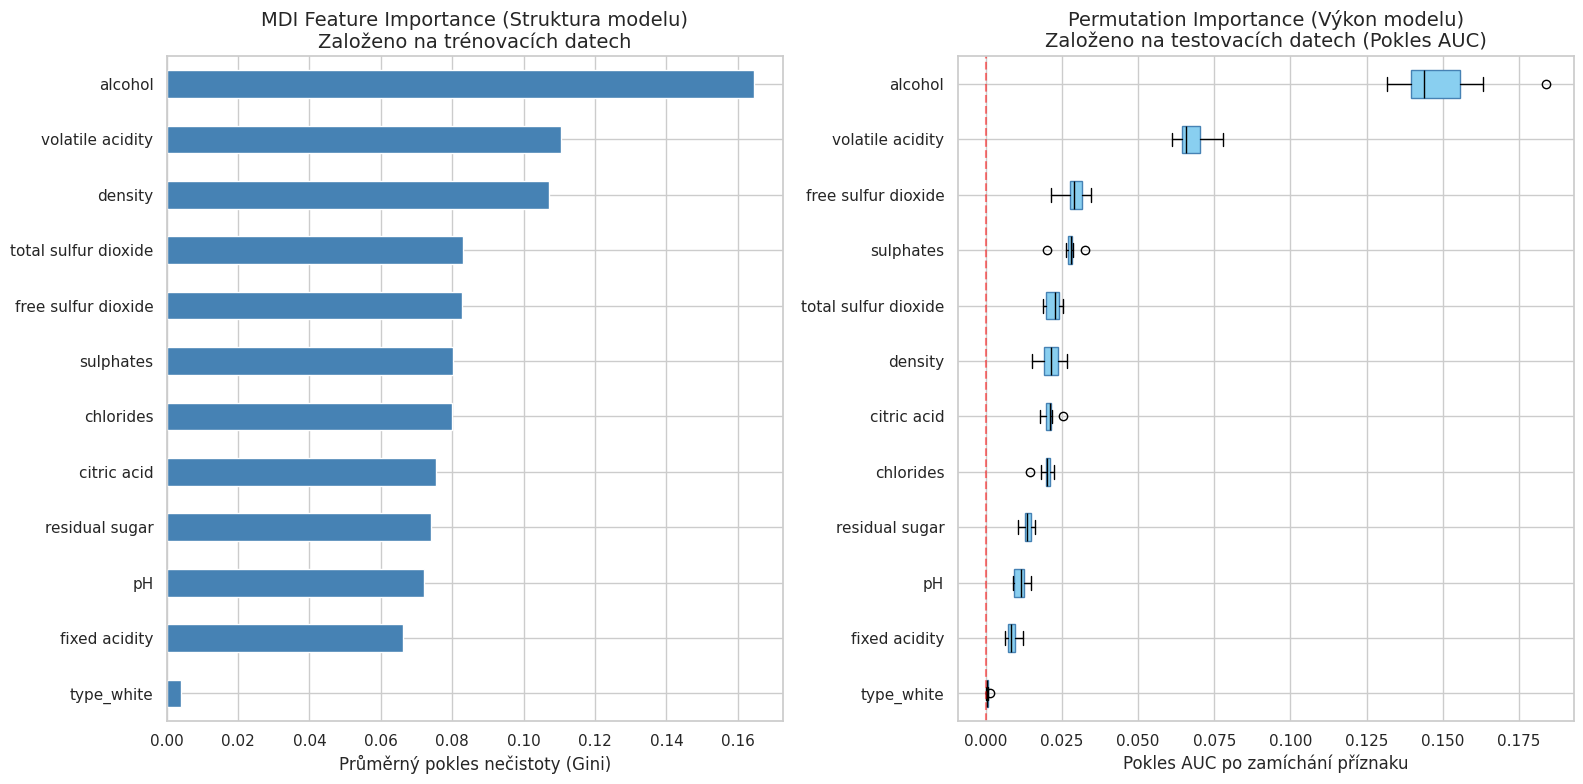

In [98]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
mdi_importances.plot(kind='barh', color='#4682B4', ax=ax1)
ax1.set_title('MDI Feature Importance (Struktura modelu)\nZaloženo na trénovacích datech', fontsize=14)
ax1.set_xlabel('Průměrný pokles nečistoty (Gini)')

ax2.boxplot(
    perm_result.importances[sorted_idx].T,
    vert=False,
    tick_labels=Xtest.columns[sorted_idx],
    patch_artist=True,
    boxprops=dict(facecolor='#89CFF0', color='#4682B4'),
    medianprops=dict(color='black')
)
ax2.set_title('Permutation Importance (Výkon modelu)\nZaloženo na testovacích datech (Pokles AUC)', fontsize=14)
ax2.set_xlabel('Pokles AUC po zamíchání příznaku')
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Interpretace
* Dominatním příznakem je alcohol v obou grafech.

#### Interepretace Feature:
* Model tento příznak nejčastěji používal v horních patrech rozhodovacích stromů k dělení dat. Je to hlavní stavební kámen modelu.

#### Interpretace Importances:
* Kdyby se "rozbil" například příznak alcohol, přesnost modelu (AUC) by drsticky klesla. Bez informace o alkoholu je správnost predikcí mizivá.

Příznak může mít vysokou Feature ale nízkou permutační důležitost, pokud je příznak korelovaný s jiným.  
Opět mezi nejdůležitejší příznaky patří alcohol a volatile_acidity.